## Linear Regression

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn import metrics

### Clean Data

In [22]:
weather = pd.read_csv("weatherdataCMSE.csv")

weather.head()

,STATION,NAME,DATE,AWND,PGTM,PRCP,TAVG,TMAX,TMIN,WDF2,WDF5,WSF2,WSF5,WT01,WT02,WT03,WT08
0,USW00014822,"DETROIT CITY AIRPORT, MI US",2015-01-01,16.33,941.0,0.00,NaN,33.0,19.0,240.0,230.0,23.9,31.1,NaN,NaN,NaN,NaN
1,USW00014822,"DETROIT CITY AIRPORT, MI US",2015-01-02,6.71,1323.0,0.00,NaN,36.0,27.0,260.0,250.0,16.1,23.0,NaN,NaN,NaN,NaN
2,USW00014822,"DETROIT CITY AIRPORT, MI US",2015-01-03,6.71,1221.0,0.38,NaN,37.0,26.0,110.0,110.0,16.1,21.0,NaN,NaN,NaN,NaN
3,USW00014822,"DETROIT CITY AIRPORT, MI US",2015-01-04,9.84,2304.0,0.07,NaN,38.0,21.0,300.0,290.0,23.9,33.1,NaN,NaN,NaN,NaN
4,USW00014822,"DETROIT CITY AIRPORT, MI US",2015-01-05,13.20,445.0,0.00,NaN,21.0,8.0,310.0,320.0,23.0,36.9,NaN,NaN,NaN,NaN


Make all N/A values 0 to use for regression models.

In [44]:
weather = weather.fillna(0)
#len(weather[weather["WT03"] == 0])
len(weather[weather["WT03"] == 1])

38

In [45]:
thunder = weather[weather["WT03"]==1]
no_thunder = weather[weather["WT03"]==0]
no_thunder = no_thunder.sample(n=38, random_state=2)
sample_t = pd.concat([thunder, no_thunder])

Create training and testing sets with the smaller data set of thunder, using precipitation, average wind speed, and peak wind gust time.

In [46]:
labels = sample_t["WT03"]
features = sample_t.iloc[:,3:6]
features
train_vectors, test_vectors, train_labels, test_labels = train_test_split(
    features,labels, test_size=.25)

In [47]:
logit_model = sm.Logit(train_labels, sm.add_constant(train_vectors))
result = logit_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.476688
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                   WT03   No. Observations:                   57
Model:                          Logit   Df Residuals:                       53
Method:                           MLE   Df Model:                            3
Date:                Thu, 20 Nov 2025   Pseudo R-squ.:                  0.3121
Time:                        18:40:12   Log-Likelihood:                -27.171
converged:                       True   LL-Null:                       -39.501
Covariance Type:            nonrobust   LLR p-value:                 1.820e-05
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5922      1.330      0.445      0.656      -2.015       3.199
AWND          -0.3330      0.

In [48]:
predicted = result.predict()
y_pred = []
for y in predicted:
    if y > .5:
        y = 1
        y_pred.append(y)
    elif y < .5:
        y = 0
        y_pred.append(y)

len(y_pred)

57

In [49]:
metrics.accuracy_score(train_labels, y_pred)

0.8070175438596491

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


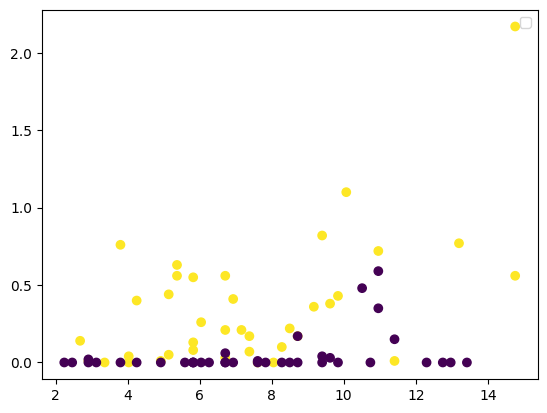

In [50]:
plt.scatter(sample_t["AWND"], sample_t["PRCP"], c=sample_t["WT03"])
plt.legend()

Same thing but remove peak wind

In [76]:
labels = sample_t["WT03"]
features = sample_t[["AWND", "PRCP"]]
features
train_vectors, test_vectors, train_labels, test_labels = train_test_split(
    features,labels, test_size=.25, random_state=6)

In [77]:
logit_model = sm.Logit(train_labels, sm.add_constant(train_vectors))
result = logit_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.505104
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                   WT03   No. Observations:                   57
Model:                          Logit   Df Residuals:                       54
Method:                           MLE   Df Model:                            2
Date:                Thu, 20 Nov 2025   Pseudo R-squ.:                  0.2711
Time:                        19:22:46   Log-Likelihood:                -28.791
converged:                       True   LL-Null:                       -39.501
Covariance Type:            nonrobust   LLR p-value:                 2.233e-05
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.2725      0.907      1.404      0.160      -0.504       3.049
AWND          -0.2955      0.

In [78]:
predicted = result.predict()
y_pred = []
for y in predicted:
    if y > .5:
        y = 1
        y_pred.append(y)
    elif y < .5:
        y = 0
        y_pred.append(y)

len(y_pred)

57

In [79]:
metrics.accuracy_score(train_labels, y_pred)

0.7719298245614035

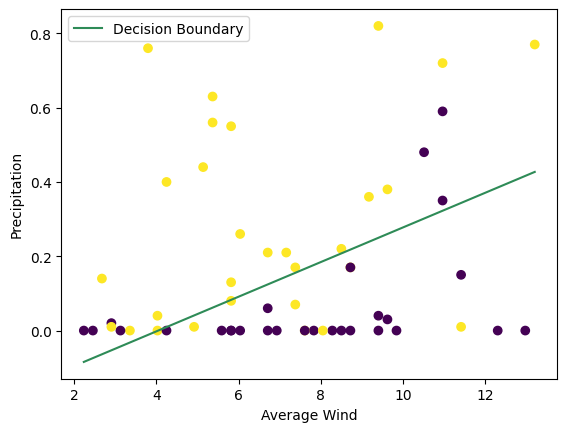

In [67]:
#coefficients

c = result.params.iloc[0]
a1 = result.params.iloc[1]
a2 = result.params.iloc[2]

#x range
x = np.linspace(train_vectors["AWND"].min(), train_vectors["AWND"].max(), 100)

#decision boundary/ classification
# c + a1(x) + a2(y) = 0
line = (-(c) - (a1*x)) / a2

#scatter plot of data in training vectors
plt.scatter(train_vectors["AWND"], train_vectors["PRCP"], c=train_labels)
plt.xlabel("Average Wind")
plt.ylabel("Precipitation")
plt.plot(x, line, color='seagreen', label="Decision Boundary")
plt.legend()

In [18]:
x = np.linspace(0,15,100)
y = .3737 - .3042(awnd) + 11.4499(prcp)

z = np.log(x)+np.log(y)


plt.scatter(sample_t["AWND"], sample_t["PRCP"], c=sample_t["WT03"])

<>:2: SyntaxWarning: 'float' object is not callable; perhaps you missed a comma?
<>:2: SyntaxWarning: 'float' object is not callable; perhaps you missed a comma?
<>:2: SyntaxWarning: 'float' object is not callable; perhaps you missed a comma?
<>:2: SyntaxWarning: 'float' object is not callable; perhaps you missed a comma?
/tmp/ipykernel_425708/3805522259.py:2: SyntaxWarning: 'float' object is not callable; perhaps you missed a comma?
  y = .3737 - .3042(awnd) + 11.4499(prcp)
/tmp/ipykernel_425708/3805522259.py:2: SyntaxWarning: 'float' object is not callable; perhaps you missed a comma?
  y = .3737 - .3042(awnd) + 11.4499(prcp)


NameError: name 'awnd' is not defined

Repeat the process using min and max temperature as the predictors for thunder.

In [37]:
labels = sample_t["WT03"]
features = sample_t.iloc[:,7:9]
features
train_vectors, test_vectors, train_labels, test_labels = train_test_split(
    features,labels, test_size=.25)

In [38]:
logit_model = sm.Logit(train_labels, sm.add_constant(train_vectors))
result = logit_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.605756
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                   WT03   No. Observations:                   57
Model:                          Logit   Df Residuals:                       54
Method:                           MLE   Df Model:                            2
Date:                Thu, 20 Nov 2025   Pseudo R-squ.:                  0.1243
Time:                        18:10:58   Log-Likelihood:                -34.528
converged:                       True   LL-Null:                       -39.430
Covariance Type:            nonrobust   LLR p-value:                  0.007429
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.4988      1.515     -2.309      0.021      -6.469      -0.529
TMAX           0.0178      0.

In [60]:
predicted = result.predict()
y_pred = []
for y in predicted:
    if y > .5:
        y = 1
        y_pred.append(y)
    elif y < .5:
        y = 0
        y_pred.append(y)

len(y_pred)

57

In [61]:
metrics.accuracy_score(train_labels, y_pred)

0.7192982456140351

InvalidIndexError: (3706     True
3770    False
3432    False
3842    False
1877     True
1647    False
3426    False
2785    False
3714    False
2788    False
3433    False
1935     True
502      True
1633     True
2787    False
1015     True
831      True
3543     True
3434    False
1158     True
2697    False
3123    False
2317     True
1664    False
2060     True
3784    False
3465     True
1841     True
3084    False
1544     True
3003     True
1161     True
3425    False
732      True
2371    False
3489    False
1367     True
1452     True
3740     True
1657    False
1682     True
3777    False
3431    False
551      True
2760     True
3741    False
1211     True
2052     True
3738    False
521      True
3771     True
3070     True
3535    False
3076     True
3872    False
2026     True
2982    False
Name: WT03, dtype: bool, 0)

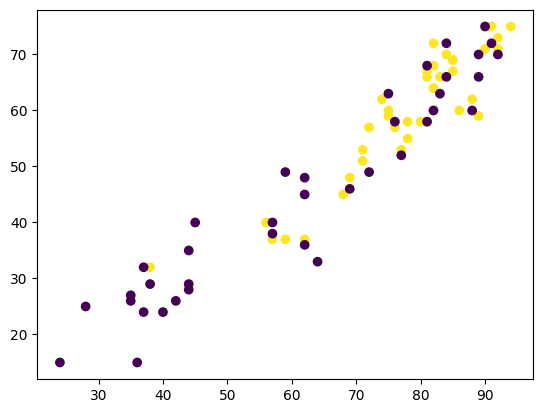

<Figure size 800x600 with 0 Axes>

In [39]:
plt.scatter(sample_t["TMAX"], sample_t["TMIN"], c=sample_t["WT03"])

plt.figure(figsize=(8, 6))
plt.scatter(train_vectors[train_labels == 0, 0], train_vectors[train_labels == 0, 1], color='blue', label='Class 0')
plt.scatter(train_vectors[train_labels == 1, 0], train_vectors[train_labels == 1, 1], color='red', label='Class 1')
plt.plot(x_values, y_values, color='green', linestyle='--', label='Decision Boundary')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Logistic Regression Decision Boundary')
plt.legend()
plt.grid(True)
plt.show()
